In [4]:
# %load_ext autoreload
# %autoreload 2

In [ ]:
from moseplib.data import config, pc_statistics, pointcloud_processing, timeseries_processing, read_rosbag
from moseplib.data.utils import Limits

# from src.visualization.utils_3d import plot_cube, plot_sphere_interactive
from mosep_analysis.data.config import RING_INNER, RING_OUTER, INTERIM_DATA_FOLDER, PROCESSED_DATA_FOLDER, FIGURE_FOLDER
from mosep_analysis.data import utils
from mosep_analysis.visualization.dash_apps import run_dash_3d_selection
from mosep_analysis.visualization import noise_plots

# from dask import delayed, compute
# from dask.diagnostics import ProgressBar
import pandas as pd
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import panel as pn

sns.set_context("paper")
sns.set_theme()
pn.extension("plotly")

#### Load Met Data from Bagfile

In [ ]:
BAG_NAME_REFERENCE = "molisens_met_2023_08_07-15_36_45_converted"
DATA_DIR_REFERENCE = INTERIM_DATA_FOLDER / "ViF_Roof" / "data"

BAG_NAME_RAIN = "molisens_met_2023_08_29-06_04_46_converted"
DATA_DIR_RAIN = INTERIM_DATA_FOLDER / "ViF_Roof" / "data"

_ = read_rosbag.get_topics_of_bagfile(DATA_DIR_REFERENCE / BAG_NAME_REFERENCE)

                                 Content of bag file                                  
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic                                     ┃ MSG                                    ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ /sensing/lidar/points2                    │ sensor_msgs/msg/PointCloud2            │
│ /clock                                    │ rosgraph_msgs/msg/Clock                │
│ /events/read_split                        │ rosbag2_interfaces/msg/ReadSplitEvent  │
│ /events/write_split                       │ rosbag2_interfaces/msg/WriteSplitEvent │
│ /sensing/lidar/os_replay/transition_event │ lifecycle_msgs/msg/TransitionEvent     │
│ /diagnostics                              │ diagnostic_msgs/msg/DiagnosticArray    │
│ /rosout                                   │ rcl_interfaces/msg/Log                 │
│ /sensing/aws/ws100_measurements           │ lufft_wsx_interfaces/msg/LufftWSXXX    │
│ /sensing/aws/ws501_measurements           │ lufft_wsx_interfaces/msg/LufftWSXXX    │
│ /sensing/lidar/metadata                   │ std_msgs/msg/String                    │
│ /sensing/lidar/points                     │ sensor_msgs/msg/PointCloud2            │
│ /tf                                       │ tf2_msgs/msg/TFMessage                 │
│ /sensing/radar/points                     │ sensor_msgs/msg/PointCloud2            │
│ /tf_static                                │ tf2_msgs/msg/TFMessage                 │
└───────────────────────────────────────────┴────────────────────────────────────────┘

In [7]:
df_reference = timeseries_processing.load(
    DATA_DIR_REFERENCE / BAG_NAME_REFERENCE,
    "/sensing/aws/ws100_measurements",
    config.PATH_TO_LUFFT_MSGS,
    timestamp_source="msg",
)
df_rain = timeseries_processing.load(
    DATA_DIR_RAIN / BAG_NAME_RAIN,
    "/sensing/aws/ws100_measurements",
    config.PATH_TO_LUFFT_MSGS,
    timestamp_source="msg",
)

Could not import custom message types. Please check your ROS installation.
Could not import custom message types. Please check your ROS installation.


In [8]:
df_rain.precipitation["differential"].value_counts()

differential
0.00    2989
0.01     520
0.02      52
0.03      11
0.04       6
0.06       5
0.09       1
0.07       1
0.08       1
Name: count, dtype: int64

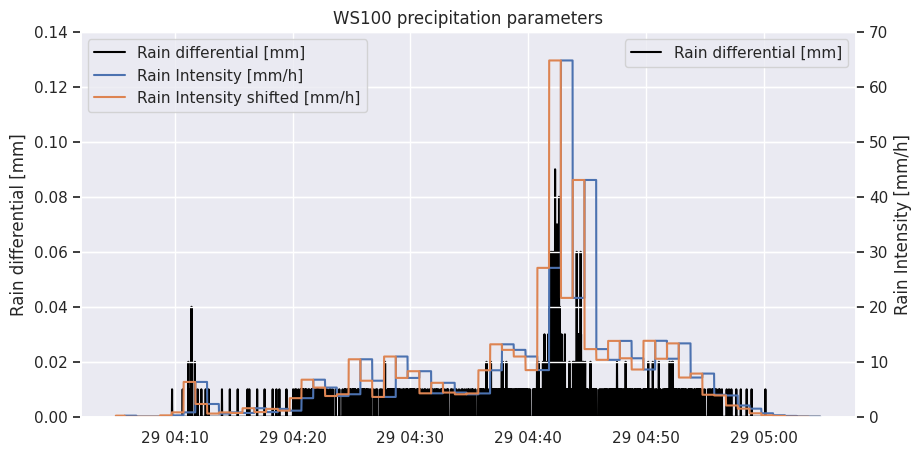

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax2 = ax.twinx()

# Seaborn lineplots for each series
sns.lineplot(
    x=df_rain.index, y=df_rain.precipitation["differential"], ax=ax, color="black", label="Rain differential [mm]"
)
sns.lineplot(x=df_rain.index, y=df_rain.precipitation["intensity_hour"], ax=ax2, label="Rain Intensity [mm/h]")
sns.lineplot(
    x=df_rain.index, y=df_rain.precipitation["intensity_hour"].shift(-60), ax=ax2, label="Rain Intensity shifted [mm/h]"
)

# Combine legends
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="upper left")

ax.set_xlabel("")
ax.set_ylabel("Rain differential [mm]")
ax2.set_ylabel("Rain Intensity [mm/h]")
ax.set_title("WS100 precipitation parameters")
ax.set_ylim(0, 0.14)
ax2.set_ylim(0, 70)
plt.show()

The Lufft WS100 rain radar returns many precipitation parameters with the two most interesting for this use case being rain intensity in mm/h and differential rain intensity in mm (which refers to the variation in precipitation intensity over time). The rain intensity is only updated every minute and as also apparent from the plot, a value for rain intensity is a sum of the previous minutes differential values (and converted to mm/h from mm/min). To account for this time delay and match the rest of the measurements rain intensity is shifted by 1 minute. **Test if true**

### Load PC data

In [10]:
TOPICS = {
    "lid_pts": "/sensing/lidar/points",
    "lid_pts2": "/sensing/lidar/points2",
    "rad_pts": "/sensing/radar/points",
}

In [24]:
dataset_reference = pointcloud_processing.load_pointcloudset(
    DATA_DIR_REFERENCE, BAG_NAME_REFERENCE, topic=TOPICS["lid_pts"], verbose=True, invert_axes=["x", "y"]
)
dataset_reference_2 = pointcloud_processing.load_pointcloudset(
    DATA_DIR_REFERENCE, BAG_NAME_REFERENCE, topic=TOPICS["lid_pts2"], verbose=True, invert_axes=["x", "y"]
)
dataset_rain = pointcloud_processing.load_pointcloudset(
    DATA_DIR_RAIN, BAG_NAME_RAIN, topic=TOPICS["lid_pts"], verbose=True, invert_axes=["x", "y"]
)
dataset_rain_2 = pointcloud_processing.load_pointcloudset(
    DATA_DIR_RAIN, BAG_NAME_RAIN, topic=TOPICS["lid_pts2"], verbose=True, invert_axes=["x", "y"]
)

Searching for pointcloudset files in:
/datalocal/chg/MOLISENSext/ViF_Roof/data/pointcloudset/sensing_lidar_points/molisens_met_2023_08_07-15_36_45_conver
ted

Dataset loaded from:
/datalocal/chg/MOLISENSext/ViF_Roof/data/pointcloudset/sensing_lidar_points/molisens_met_2023_08_07-15_36_45_conver
ted

 start =    2023-08-07 13:36:48.072408
 end =      2023-08-07 13:39:47.651742
 duration = 0:02:59.579334
 length =   1795
 avg frequency =  10.00 Hz

Inverting axes: ['x', 'y']


Searching for pointcloudset files in:
/datalocal/chg/MOLISENSext/ViF_Roof/data/pointcloudset/sensing_lidar_points2/molisens_met_2023_08_07-15_36_45_conve
rted

Dataset loaded from:
/datalocal/chg/MOLISENSext/ViF_Roof/data/pointcloudset/sensing_lidar_points2/molisens_met_2023_08_07-15_36_45_conve
rted

 start =    2023-08-07 13:36:47.984902
 end =      2023-08-07 13:39:47.651742
 duration = 0:02:59.666840
 length =   1798
 avg frequency =  10.01 Hz

...

Dataset loaded from:
/datalocal/chg/MOLISENSext/ViF_Roof/data/pointcloudset/sensing_lidar_points/molisens_met_2023_08_29-06_04_46_conver
ted

 start =    2023-08-29 04:05:19.853657
 end =      2023-08-29 05:04:46.069975
 duration = 0:59:26.216318
 length =   35659
 avg frequency =  10.00 Hz

Inverting axes: ['x', 'y']


Searching for pointcloudset files in:
/datalocal/chg/MOLISENSext/ViF_Roof/data/pointcloudset/sensing_lidar_points2/molisens_met_2023_08_29-06_04_46_conve
rted

Dataset loaded from:
/datalocal/chg/MOLISENSext/ViF_Roof/data/pointcloudset/sensing_lidar_points2/molisens_met_2023_08_29-06_04_46_conve
rted

 start =    2023-08-29 04:05:19.853657
 end =      2023-08-29 05:04:46.069975
 duration = 0:59:26.216318
 length =   35664
 avg frequency =  10.00 Hz

Inverting axes: ['x', 'y']


In [23]:
pointcloud_processing.print_stats(DATA_DIR_REFERENCE / BAG_NAME_REFERENCE, dataset_reference)

Dataset loaded from:
/datalocal/chg/MOLISENSext/ViF_Roof/data/molisens_met_2023_08_07-15_36_45_converted

 start =    2023-08-07 13:36:48.072408
 end =      2023-08-07 13:39:47.651742
 duration = 0:02:59.579334
 length =   1795
 avg frequency =  10.00 Hz

In [28]:
# _ = [
#     print(xn, f"{x:.2f}", yn, f"{y:.2f}", sep="\t")
#     for (xn, x), (yn, y) in zip(dataset_reference.min().iteritems(), dataset_reference.max().iteritems())
# ]

Plot an example point cloud.

In [10]:
# fig = (
#     dataset_rain[20000]
#     # .limit(dim="intensity", minvalue=0, maxvalue=500)
#     .plot(color="intensity", hover_data=["intensity"])
# )
# fig.update_layout(template="gridon", autosize=False, width=1000, height=800)
# fig

dataset_reference.animate(hover_data=True, color="intensity")

### Resample Dataset to 1s


In [11]:
rain_ds_seconds = utils.load_or_calculate(
    PROCESSED_DATA_FOLDER / f"rain_seconds_{BAG_NAME_RAIN}.pickle",
    pointcloud_processing.resample_dataset,
    ds=dataset_rain[20 * 10 :],
    resampling_period="1s",
    extra_statistics=["std", "sum"],
)

### Resample Dataset to 1min

In [12]:
rain_ds_minutes = utils.load_or_calculate(
    PROCESSED_DATA_FOLDER / f"rain_minutes_{BAG_NAME_RAIN}.pickle",
    pointcloud_processing.resample_dataset,
    ds=dataset_rain[20 * 10 :],
    resampling_period="1min",
    extra_statistics=["std", "sum"],
)

In [13]:
rain_ds_minutes_2 = utils.load_or_calculate(
    PROCESSED_DATA_FOLDER / f"rain_minutes_return2_{BAG_NAME_RAIN}.pickle",
    pointcloud_processing.resample_dataset,
    ds=dataset_rain_2[20 * 10 :],
    resampling_period="1min",
    extra_statistics=["std", "sum"],
)

## Mean point cloud

In [14]:
# # print(dataset_reference[0:10].mean())
# # print(dataset_reference[0:10].mean("pointcloud"))
# mean_cloud_ref = dataset_reference[500:600].mean("point").dropna()
# mean_cloud_rain = dataset_rain[500:600].mean("point").dropna()
# mean_cloud_ref = mean_cloud_ref.rename(columns={"x mean": "x", "y mean": "y", "z mean": "z"})
# mean_cloud_rain = mean_cloud_rain.rename(columns={"x mean": "x", "y mean": "y", "z mean": "z"})
# mean_cloud_ref.reset_index(inplace=True)
# mean_cloud_rain.reset_index(inplace=True)
# # print(mean_cloud_ref)

In [15]:
# fig = PointCloud(mean_cloud_rain, columns=["x mean", "y mean", "z mean"]).plot(
#     hover_data=True,
#     color="N",
#     width=800,
#     height=800,
#     overlay={"mean_cloud_ref": PointCloud(mean_cloud_ref, columns=["x mean", "y mean", "z mean"])},
# )
# fig

## Statistics of Noise Ring


### Isolate rings

In [16]:
# rain_ds_minutes["sum"].daskdataframe.dask
# rain_ds_minutes["sum"].daskdataframe.visualize(engine="cytoscape", optimize_graph=True)

In [18]:
# app = run_dash_3d_selection(
#     rain_ds_minutes["sum"].apply(RING_OUTER.apply_limits)[1].data, c_column="intensity", color_range=(0, 200)
# )
# app.run(jupyter_mode="external", port=8052)

### ToDos

- [ ] Make functions of plots and plot all nine variants + correlation matrix.
- [ ] Make 2D plots of all points aggregated.
- [ ] Does the second return have a benefit?
- [ ] Does the ds aggregated to seconds have a benefit when compared with differential rain intensity?
- [ ] Decide on approach



In [125]:
limit_intensity = Limits(i_max=1_000)
limit_n_points = Limits(n_max=20)  # this is different for minutes and seconds

exclude = {
    "ws100": Limits(x_min=7.39, x_max=7.77, y_min=-1.65, y_max=-1.39, z_min=-0.16, z_max=0.41),
    "ws501": Limits(x_min=6.086, x_max=6.43, y_min=-1.64, y_max=-1.39, z_min=-0.16, z_max=0.51),
    "wall_left": Limits(x_min=-1.0, x_max=20, y_min=3.26, y_max=6, z_min=-0.2, z_max=0.18),
    "box_1": Limits(x_min=-1.0, x_max=2.42, y_min=2.01, y_max=3.26, z_min=-0.2, z_max=0.18),
    "box_2": Limits(x_min=5.97, x_max=8.43, y_min=2.31, y_max=3.26, z_min=-0.2, z_max=-0.04),
    "pole_1": Limits(x_min=1.06, x_max=1.46, y_min=1.36, y_max=1.8, z_min=-0.2, z_max=0.73),
    "pole_2": Limits(x_min=0.25, x_max=0.38, y_min=-3.45, y_max=-3.19, z_min=-0.2, z_max=1.28),
    "pole_3": Limits(x_min=7.21, x_max=7.61, y_min=1.45, y_max=1.66, z_min=-0.2, z_max=1.47),
    "pole_4": Limits(x_min=10.5, x_max=10.59, y_min=1.95, y_max=2.13, z_min=-0.2, z_max=1.52),
    "pole_5": Limits(x_min=13.49, x_max=13.96, y_min=1.00, y_max=1.33, z_min=-0.2, z_max=3.49),
    "pole_6": Limits(x_min=14.09, x_max=14.38, y_min=10.35, y_max=10.75, z_min=-0.2, z_max=4.50),
}

In [141]:
# Isolate the inner and outer ring by applying limit to dataset
## Minutes
rain_ds_minutes_ring_c = rain_ds_minutes["sum"].apply(RING_INNER.apply_limits)
rain_ds_minutes_ring_w = (
    rain_ds_minutes["sum"]
    .apply(RING_OUTER.apply_limits)
    # .apply(limit_intensity.apply_limits)
    .apply(limit_n_points.apply_limits)
)
for key, value in exclude.items():
    rain_ds_minutes_ring_w = rain_ds_minutes_ring_w.apply(value.apply_exclude)


## Minutes 2
with warnings.catch_warnings(record=True):
    rain_ds_minutes_2_ring_c = rain_ds_minutes_2["sum"].apply(RING_INNER.apply_limits)
    rain_ds_minutes_2_ring_w = (
        rain_ds_minutes_2["sum"].apply(RING_OUTER.apply_limits)
        # .apply(limit_intensity.apply_limits)
        # .apply(limit_n_points.apply_limits)
    )
    for key, value in exclude.items():
        rain_ds_minutes_2_ring_w = rain_ds_minutes_2_ring_w.apply(value.apply_exclude)


## Seconds
with warnings.catch_warnings(record=True):
    rain_ds_seconds_ring_c = rain_ds_seconds["sum"].apply(RING_INNER.apply_limits)
    rain_ds_seconds_ring_w = (
        rain_ds_seconds["sum"].apply(RING_OUTER.apply_limits)
        # .apply(limit_intensity.apply_limits)
        # .apply(limit_n_points.apply_limits)
    )
    for key, value in exclude.items():
        rain_ds_seconds_ring_w = rain_ds_seconds_ring_w.apply(value.apply_exclude)

In [127]:
# Go through individual point clouds
# with warnings.catch_warnings(record=True):
#     fig = rain_ds_seconds_ring_w[35 * 60 : 37 * 60].animate(hover_data=True, color="intensity")
# fig

In [128]:
IND = 36 * 60 + 27
# RW = rain_ds_minutes_ring_w[IND]
# RC = rain_ds_minutes_ring_c[IND]
# RW = rain_ds_minutes_2_ring_w[IND]
# RC = rain_ds_minutes_2_ring_c[IND]
RW = rain_ds_seconds_ring_w[IND]
RC = rain_ds_seconds_ring_c[IND]

fig = noise_plots.plot3d(RW, RC, exclude)
fig

In [129]:
fig.write_image(
    FIGURE_FOLDER / "rain_minutes_ring_wide_npoints_zoom_0435.svg",
)

### 2D Projections of aggregated point clouds

In [130]:
import open3d as o3d


def test(pc):
    return pc.to_instance("OPEN3D")


fig = o3d.visualization.draw_plotly(rain_ds_minutes_ring_w.apply(test).compute())


No return type was defined in test:will not return a new dataset


In [131]:
df = rain_ds_minutes_ring_w.agg("mean", "point")


<Axes: xlabel='x mean', ylabel='z mean'>

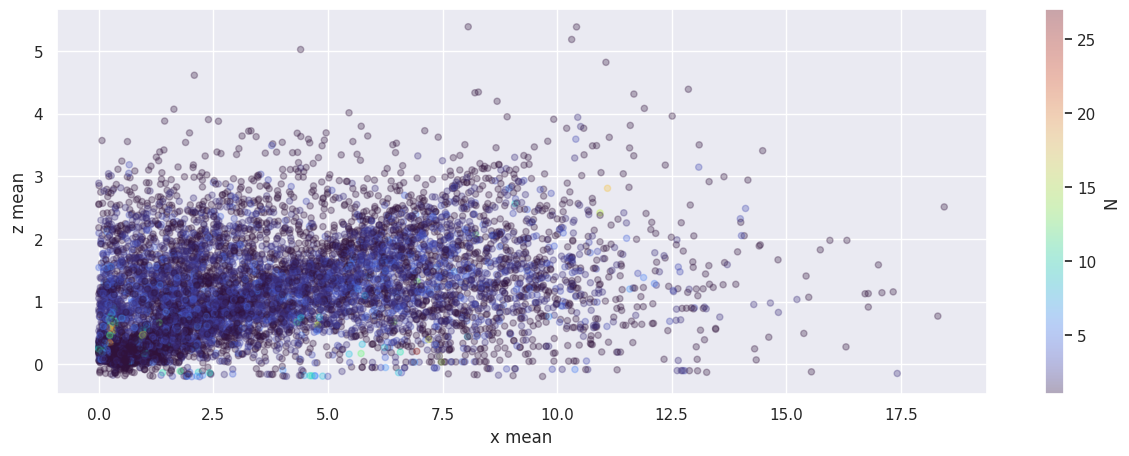

In [132]:
df.plot(
    x="x mean", y="z mean", kind="scatter", c="N", colormap="turbo", alpha=0.3, figsize=(15, 5), backend="matplotlib"
)

In [133]:
# df_all.hvplot.scatter(x="x", y="y", datashade=True, c="N", cmap="plasma", colorbar=True, width=800, height=500)

### Result plots

Prepare weather data for plotting.

In [134]:
df_rain.index = df_rain.index.round(freq="S")  # Round to the nearest second
rr_differ = df_rain.precipitation.differential

rr_tpp = df_rain.precipitation.total_precipitation_particles

rr_int_h = df_rain.precipitation.intensity_hour  # .resample("1s").mean()
# Shift precipitation intensity hour to account for the AWS averaging duration
rr_int_h = rr_int_h.shift(periods=-60, freq="s")
rr_int_h = rr_int_h[60:]

In [135]:
n_points_ring_close_minutes = pd.concat(rain_ds_minutes_ring_c.apply(pc_statistics.n_points))
n_points_ring_wide_minutes = pd.concat(rain_ds_minutes_ring_w.apply(pc_statistics.n_points))

n_points_ring_close_minutes_2 = pd.concat(rain_ds_minutes_2_ring_c.apply(pc_statistics.n_points))
n_points_ring_wide_minutes_2 = pd.concat(rain_ds_minutes_2_ring_w.apply(pc_statistics.n_points))

n_points_ring_close_seconds = utils.load_or_calculate(
    PROCESSED_DATA_FOLDER / f"n_points_ring_close_seconds_{BAG_NAME_RAIN}.pickle",
    lambda: pd.concat(rain_ds_minutes_ring_c.apply(pc_statistics.n_points)),
)
n_points_ring_wide_seconds = utils.load_or_calculate(
    PROCESSED_DATA_FOLDER / f"n_points_ring_wide_seconds_{BAG_NAME_RAIN}.pickle",
    lambda: pd.concat(rain_ds_minutes_ring_w.apply(pc_statistics.n_points)),
)

In [136]:
NPRC = n_points_ring_close_minutes
NPRW = n_points_ring_wide_minutes

fig = noise_plots.temporal_development(nrpc=NPRC, nrpw=NPRW, rr_differ=None, rr_int_h=rr_int_h)
fig

In [137]:
fig.write_image(FIGURE_FOLDER / "rainfall_vs_noise.png", scale=5)

## Correlation

Erkenntnisse:
The more we aggregate torwards 1min the heigher the correlation gets (.resample("10s").sum(), .resample("30s").sum(), etc.).

<Axes: >

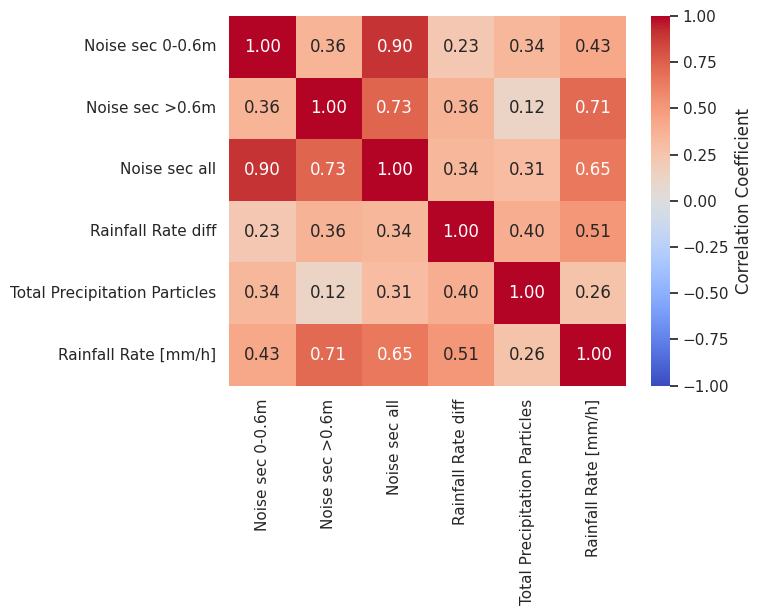

In [138]:
df_corr_s = pd.DataFrame(
    {
        "Noise sec 0-0.6m": n_points_ring_close_seconds,
        "Noise sec >0.6m": n_points_ring_wide_seconds,
        "Noise sec all": n_points_ring_wide_seconds + n_points_ring_close_seconds,
    }
)
df_corr_s["Rainfall Rate diff"] = rr_differ
df_corr_s["Total Precipitation Particles"] = rr_tpp
df_corr_s["Rainfall Rate [mm/h]"] = rr_int_h
df_corr_s.corr()
sns.heatmap(
    df_corr_s.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Correlation Coefficient"},
)


In [139]:
import numpy as np

<Axes: >

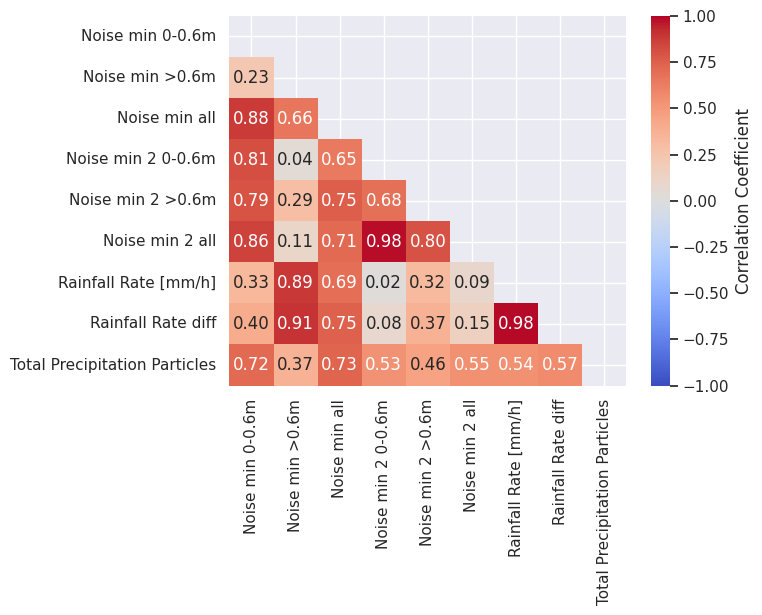

In [140]:
df_corr_min = pd.DataFrame(
    {
        "Noise min 0-0.6m": n_points_ring_close_minutes,
        "Noise min >0.6m": n_points_ring_wide_minutes,
        "Noise min all": n_points_ring_wide_minutes + n_points_ring_close_minutes,
        "Noise min 2 0-0.6m": n_points_ring_close_minutes_2,
        "Noise min 2 >0.6m": n_points_ring_wide_minutes_2,
        "Noise min 2 all": n_points_ring_wide_minutes_2 + n_points_ring_close_minutes_2,
    }
)
df_corr_min["Rainfall Rate [mm/h]"] = rr_int_h.resample("1min").first()
df_corr_min["Rainfall Rate diff"] = rr_differ.resample("1min").sum()
df_corr_min["Total Precipitation Particles"] = rr_tpp.resample("1min").sum()
df_corr_min.corr()
sns.heatmap(
    df_corr_min.corr(),
    mask=np.triu(df_corr_min.corr()),  # Mask the lower triangle
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Correlation Coefficient"},
)